# Financial Fraud Detection System
## Exploratory Data Analysis and Machine Learning Project

## Project Overview

This project focuses on detecting fraudulent financial transactions using Machine Learning techniques. The objective is to analyze transaction patterns, identify suspicious activities, and build predictive models to classify fraudulent and non-fraudulent transactions.

The project includes:
- Data Cleaning and Preprocessing
- Exploratory Data Analysis (EDA)
- Fraud Pattern Visualization
- Machine Learning Model Building
- Model Evaluation and Comparison

#  Data Loading and Understanding

In [1]:
import pandas as pd
df=pd.read_csv("financial_fraud_detection_dataset.csv")
df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent
0,T100000,CUST3252,04-10-2023 07:45,37.54,Travel,PayPal,POS,Bengaluru,0,94,417.40,1492,No,0
1,T100001,CUST1630,26-09-2023 08:29,240.81,Utilities,PayPal,Mobile,Bengaluru,0,76,335.47,66,No,0
2,T100002,CUST7852,18-07-2023 15:54,105.34,Entertainment,Debit Card,Mobile,Bengaluru,0,60,432.03,216,No,0
3,T100003,CUST4892,16-10-2023 17:10,73.04,Utilities,NetBanking,Desktop,Kolkata,0,68,488.30,449,No,0
4,T100004,CUST8831,09-09-2023 00:46,13.57,Utilities,Credit Card,Desktop,Bengaluru,0,57,437.03,754,No,0


# Data Cleaning and Preprocessing

In [2]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Transaction_Date',
       'Transaction_Amount', 'Merchant_Category', 'Payment_Method',
       'Device_Type', 'Location', 'Is_International', 'Previous_Transactions',
       'Average_Spend', 'Account_Age_Days', 'Suspicious_Keyword',
       'Fraudulent'],
      dtype='object')

In [3]:
df.shape

(5000, 14)

In [4]:
# Checking Missing Values

df.isnull().sum()

Transaction_ID           0
Customer_ID              0
Transaction_Date         0
Transaction_Amount       0
Merchant_Category        0
Payment_Method           0
Device_Type              0
Location                 0
Is_International         0
Previous_Transactions    0
Average_Spend            0
Account_Age_Days         0
Suspicious_Keyword       0
Fraudulent               0
dtype: int64

# Exploratory Data Analysis (EDA)

In [5]:
# Fraud vs Non-Fraud Transactions Count

df['Fraudulent'].value_counts()

Fraudulent
0    4518
1     482
Name: count, dtype: int64

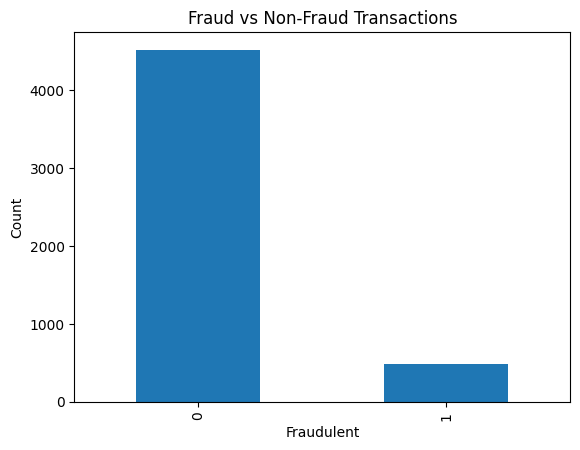

In [6]:
# ============================================
# Fraud vs Non-Fraud Transactions Visualization
# ============================================

import matplotlib.pyplot as plt

df['Fraudulent'].value_counts().plot(kind='bar')

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraudulent")
plt.ylabel("Count")

plt.show()

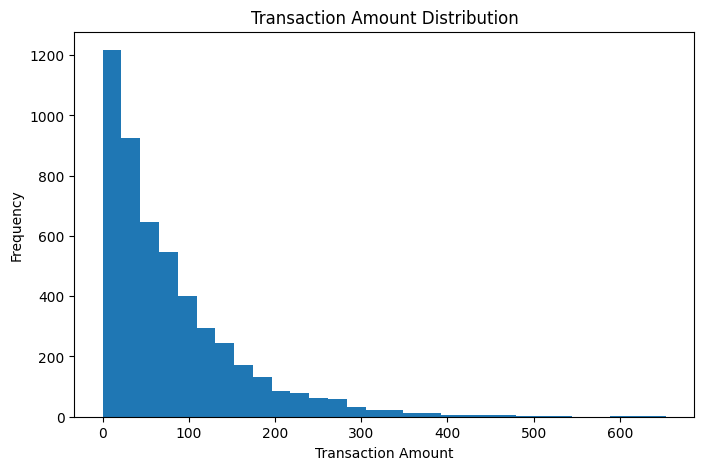

In [7]:
# ============================================
# Transaction Amount Distribution
# ============================================

plt.figure(figsize=(8,5))

plt.hist(df['Transaction_Amount'], bins=30)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

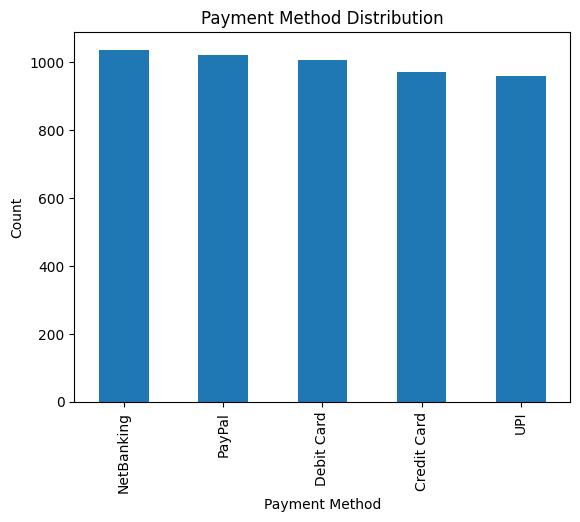

In [8]:
# ============================================
# Payment Method Analysis
# ============================================

df['Payment_Method'].value_counts().plot(kind='bar')

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Count")

plt.show()

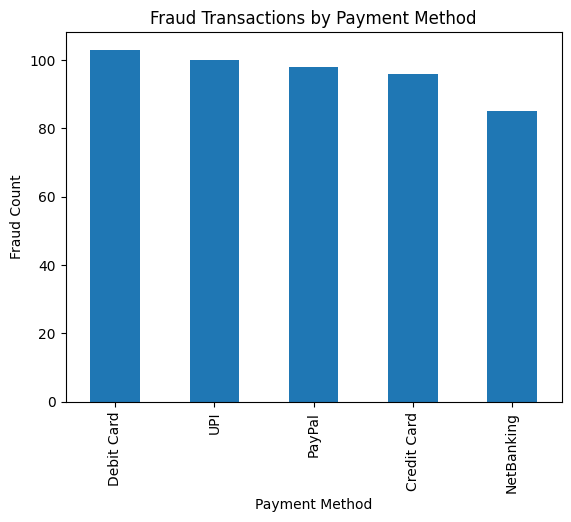

In [9]:
# ============================================
# Fraud Transactions by Payment Method
# ============================================

fraud_data = df[df['Fraudulent'] == 1]

fraud_data['Payment_Method'].value_counts().plot(kind='bar')

plt.title("Fraud Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fraud Count")

plt.show()

In [11]:
# ============================================
# Encoding Categorical Columns
# ============================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Merchant_Category'] = encoder.fit_transform(df['Merchant_Category'])
df['Payment_Method'] = encoder.fit_transform(df['Payment_Method'])
df['Device_Type'] = encoder.fit_transform(df['Device_Type'])
df['Location'] = encoder.fit_transform(df['Location'])
df['Suspicious_Keyword'] = encoder.fit_transform(df['Suspicious_Keyword'])

df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent
0,T100000,CUST3252,04-10-2023 07:45,37.54,6,3,2,0,0,94,417.40,1492,0,0
1,T100001,CUST1630,26-09-2023 08:29,240.81,7,3,1,0,0,76,335.47,66,0,0
2,T100002,CUST7852,18-07-2023 15:54,105.34,1,1,1,0,0,60,432.03,216,0,0
3,T100003,CUST4892,16-10-2023 17:10,73.04,7,2,0,4,0,68,488.30,449,0,0
4,T100004,CUST8831,09-09-2023 00:46,13.57,7,0,0,0,0,57,437.03,754,0,0


# Machine Learning Model

In [12]:
# ============================================
# Feature Selection
# ============================================

X = df.drop(['Transaction_ID',
             'Customer_ID',
             'Transaction_Date',
             'Fraudulent'], axis=1)

y = df['Fraudulent']

print(X.head())
print(y.head())

   Transaction_Amount  Merchant_Category  Payment_Method  Device_Type  \
0               37.54                  6               3            2   
1              240.81                  7               3            1   
2              105.34                  1               1            1   
3               73.04                  7               2            0   
4               13.57                  7               0            0   

   Location  Is_International  Previous_Transactions  Average_Spend  \
0         0                 0                     94         417.40   
1         0                 0                     76         335.47   
2         0                 0                     60         432.03   
3         4                 0                     68         488.30   
4         0                 0                     57         437.03   

   Account_Age_Days  Suspicious_Keyword  
0              1492                   0  
1                66                   0  
2       

In [17]:
# ============================================
# Train-Test Split
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (4000, 10)
Testing Data Shape: (1000, 10)


In [19]:
# ============================================
# Logistic Regression Model
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training
model = LogisticRegression(max_iter=2000)

model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

print("Model Training Completed Successfully")

Model Training Completed Successfully


In [20]:
# ============================================
# Model Evaluation
# ============================================

from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.905

Classification Report:

              precision    recall  f1-score   support

           0       0.91      1.00      0.95       901
           1       0.83      0.05      0.10        99

    accuracy                           0.91      1000
   macro avg       0.87      0.52      0.52      1000
weighted avg       0.90      0.91      0.87      1000



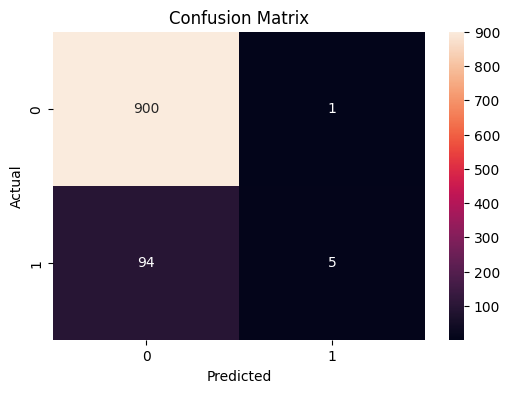

In [21]:
# ============================================
# Confusion Matrix
# ============================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Random Forest Model

In [23]:
# ============================================
# Random Forest Model
# ============================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Model Training
rf_model.fit(X_train, y_train)

# Prediction
rf_y_pred = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [24]:
# ============================================
# Random Forest Model Evaluation
# ============================================

from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_test, rf_y_pred)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, rf_y_pred))

Random Forest Accuracy: 0.907

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.99      0.95       901
           1       0.67      0.12      0.21        99

    accuracy                           0.91      1000
   macro avg       0.79      0.56      0.58      1000
weighted avg       0.89      0.91      0.88      1000



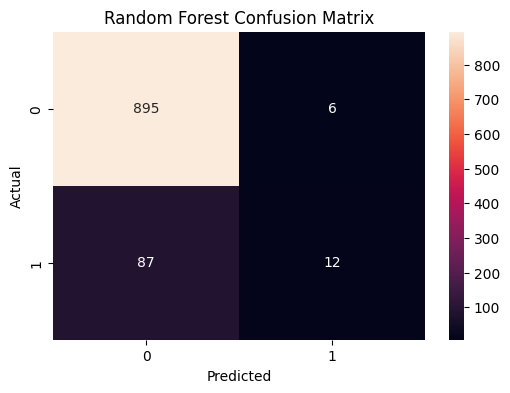

In [25]:
# ============================================
# Random Forest Confusion Matrix
# ============================================

rf_cm = confusion_matrix(y_test, rf_y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(rf_cm, annot=True, fmt='d')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Model Comparison

- Logistic Regression Accuracy: 90.5%
- Random Forest Accuracy: 90.7%

## Observation
Random Forest performed slightly better than Logistic Regression in detecting fraudulent transactions.

## Final Selected Model
Random Forest Classifier

# Conclusion

- A Financial Fraud Detection System was successfully developed using Machine Learning techniques.
- Exploratory Data Analysis (EDA) was performed to identify transaction patterns and fraud behavior.
- Multiple visualizations were created to understand fraud distribution and payment trends.
- Logistic Regression and Random Forest models were implemented and evaluated.
- Random Forest performed better with approximately 90.7% accuracy.
- The project demonstrates how Machine Learning can help financial institutions identify suspicious transactions efficiently.
- This system can be further improved using advanced models and real-time fraud monitoring techniques.